In [292]:
"""Run this to establish the connection with the database"""
# load the SQL extension
%load_ext sql

# create the connection string
import os
user = os.getenv('postgres_user')
password = os.getenv('postgres_password')
db = os.getenv('postgres_db')
db_url = f"postgresql://{user}:{password}@db/{db}"

# establish the connection
from sqlalchemy import create_engine
engine = create_engine(db_url)

# set %sql magic commands to use the connection
%sql engine

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [87]:
%%sql
select
    name,
    pct_snap_retailers
from county_analytics_view
    where ct_snap_retailers > 20
order by 2 desc

Running query in 'postgresql://healthgps:***@db/healthgps'

1842 rows affected.

name,pct_snap_retailers
TIFT,100.0000000000000000
GREEN,100.0000000000000000
KUSILVAK,100.0000000000000000
DE SOTO,100.0000000000000000
HOCKLEY,100.0000000000000000
MADISON,100.0000000000000000
WASHINGTON,100.0000000000000000
JUNEAU,100.0000000000000000
BROOKE,100.0000000000000000
PRENTISS,100.0000000000000000


In [88]:
"""You can optionally pull this into a pandas dataframe"""
results_df = %sql select * from food_posts

Running query in 'postgresql://healthgps:***@db/healthgps'

51732 rows affected.

In [6]:
%%sql
-- Check for duplicates between SNAP retailers and access food pantries
SELECT
    a."Store_Name" as id,
    b.name as pantry_name,
    st_distance(a.geometry, b.geometry::geography, False) as dist
FROM snap_retailers_raw a
CROSS JOIN LATERAL (
  SELECT
    "locationName" as name,
    pantries.geometry
  FROM access_food_foodbanks_raw pantries
  ORDER BY
         pantries.geometry <-> a.geometry -- nearest neighbor
  LIMIT  1
) AS b
order by 3 asc
limit 1000

Running query in 'postgresql://healthgps:***@db/healthgps'

1000 rows affected.

id,pantry_name,dist
Metro Atlanta Urban Farm,Metro Atlanta Urban Farm in College Park Inc.,0.38149356
Gipson Grocery,Southside Economic & Community Dev Corp,1.12890312
DOLLARTREE 10245,Nations Church,1.38239265
Hiouchi Market,Hiouchi Hamlet,1.99638061
Southeastern Farmers Market,Southeastern Church of Christ,2.0538576
For Oak Cliff Farmers Market NAFMNP,For Oak Cliff,2.06219117
Harar Market,Colorado Muslim Community Center,2.24415485
Brighton Winter Farmer's Market NAFMNP,ABCD/Allston Brighton,2.3780434
Gric Market 817,Gila Indian River Community,2.84057335
Muncie Common Market,The Common Market,3.36015309


In [28]:
sql = """select
    a.id as a_id,
    b.id as b_id,
    ARRAY(SELECT element FROM unnest(ARRAY[a.id, b.id]) AS element ORDER BY element),
    a.name as a_name,
    b.name as b_name,
    a.address as a_address,
    b.address as b_address,
    a.phone_number_1 as a_pn_1,
    b.phone_number_1 as b_pn_1,
    a.phone_number_2 as a_pn_2,
    b.phone_number_2 as b_pn_2,
    a.source as a_source,
    b.source as b_source,
    st_distance(a.geometry::geography, b.geometry::geography) as dist
from food_posts a
cross join lateral (
    select
        id,
        name,
        address,
        phone_number_1,
        phone_number_2,
        source,
        geometry
    from food_posts f
    where f.id <> a.id
    order by f.geometry <-> a.geometry
    limit 1
) b"""

In [29]:
df = pandas.read_sql(sql,con=engine)

In [37]:
df[(df['dist']<10) & (df['a_name']==df['b_name']) | (df['a_pn_1']==df['b_pn_1'])]

,a_id,b_id,array,a_name,b_name,a_address,b_address,a_pn_1,b_pn_1,a_pn_2,b_pn_2,a_source,b_source,dist
0,c9277530-a3b1-4fd9-8c7c-8244f1fcde42,1e2133f7-8565-4404-b2cc-53557389e970,"[1e2133f7-8565-4404-b2cc-53557389e970, c927753...",BREATH OF GOD FEEDING PROGRAM,BREATH OF GOD FEEDING PROGRAM,None,"141 SOUTH CLINTON STREET, BALTIMORE, MARYLAND,...",None,410-675-5616,None,None,md_food_bank,why_hunger_api,1.286851
1,cfd1e907-00a7-494c-aeea-55381c5e347d,b6655aac-b17f-40c0-a729-305be05b2131,"[b6655aac-b17f-40c0-a729-305be05b2131, cfd1e90...",SOUTH CREEK COMMUNITY DEVELOPMENT CORPORATION,SOUTH CREEK COMMUNITY DEVELOPMENT CORPORATION,None,None,None,None,None,None,md_food_bank,md_food_bank,0.000000
2,b6655aac-b17f-40c0-a729-305be05b2131,cfd1e907-00a7-494c-aeea-55381c5e347d,"[b6655aac-b17f-40c0-a729-305be05b2131, cfd1e90...",SOUTH CREEK COMMUNITY DEVELOPMENT CORPORATION,SOUTH CREEK COMMUNITY DEVELOPMENT CORPORATION,None,None,None,None,None,None,md_food_bank,md_food_bank,0.000000
5,24bc3a1b-3339-4191-992d-789334547e36,440ef1c3-e9cf-4b7e-9d48-d9dae8fc95e6,"[24bc3a1b-3339-4191-992d-789334547e36, 440ef1c...",LIFE CHURCH MINISTRIES,LIFE CHURCH MINISTRIES,None,"3820 SOUTH HANOVER STREET, BALTIMORE, MARYLAND...",None,443-708-8537,None,None,md_food_bank,why_hunger_api,1.531069
11,9aedcafa-5244-442e-a931-8f52f3fadd25,17f90922-0ab8-4b70-bca8-583fec87ea99,"[17f90922-0ab8-4b70-bca8-583fec87ea99, 9aedcaf...",MACEDONIA PROJECT,MACEDONIA PROJECT,None,"5401 FRANKFORD AVENUE, BALTIMORE, MARYLAND, 21...",None,410-488-5650,None,None,md_food_bank,why_hunger_api,0.389869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51724,b39fe883-c7b5-40e1-ae41-c46195bef6ec,051b958e-1771-4729-ab19-e61cf8c50da1,"[051b958e-1771-4729-ab19-e61cf8c50da1, b39fe88...",BYLAS FOOD DISTRIBUTION,BYLAS FOOD DISTRIBUTION PROGRAM,"RAINBOW CITY CIR #2, SAN CARLOS, AZ, 85550","RAINBOW CITY CIRCLE BUILDING 2, BYLAS, AZ, 85...",928-475-2304,928-475-2304,None,None,access_food_api,access_food_api,36.806348
51725,c7a4064c-c364-4a5a-ad08-ad238b102f71,c401ed4c-7774-43a4-80c5-62dc782911ba,"[c401ed4c-7774-43a4-80c5-62dc782911ba, c7a4064...",FLAGSTAFF FAMILY FOOD CENTER: SUMMIT HIGH SCHOOL,FLAGSTAFF FAMILY FOOD CENTER: WAREHOUSE FOOD BANK,"4000 N CUMMINGS ST, FLAGSTAFF, AZ, 86004","3805 E HUNTINGTON DR, FLAGSTAFF, AZ, 86004",928-526-2211,928-526-2211,928-526-2211,928-526-2211,access_food_api,access_food_api,1575.591811
51728,dedf8a09-4fc1-4277-9fb0-d51f161d9b16,b5f7de8a-4664-402a-a855-e45c4cf43de8,"[b5f7de8a-4664-402a-a855-e45c4cf43de8, dedf8a0...",SMFB AT KAIBAB PAIUTE,SMFB AT KAIBAB (TURKEY DISTRIBUTION),"600 N PINE SPRINGS RD, FREDONIA, AZ, 86022","600 N PINE SPRINGS RD, FREDONIA, AZ, 86022",928-220-5335,928-220-5335,928-220-5335,928-220-5335,access_food_api,access_food_api,0.242619
51729,b5f7de8a-4664-402a-a855-e45c4cf43de8,dedf8a09-4fc1-4277-9fb0-d51f161d9b16,"[b5f7de8a-4664-402a-a855-e45c4cf43de8, dedf8a0...",SMFB AT KAIBAB (TURKEY DISTRIBUTION),SMFB AT KAIBAB PAIUTE,"600 N PINE SPRINGS RD, FREDONIA, AZ, 86022","600 N PINE SPRINGS RD, FREDONIA, AZ, 86022",928-220-5335,928-220-5335,928-220-5335,928-220-5335,access_food_api,access_food_api,0.242619


In [105]:
df23 = pandas.read_csv('cps_fss_dec23.csv')
df22 = pandas.read_csv('cps_fss_dec22.csv')
df21 = pandas.read_csv('cps_fss_dec21.csv')
df20 = pandas.read_csv('cps_fss_dec20.csv')
df19 = pandas.read_csv('cps_fss_dec19.csv')

In [106]:
df = pandas.concat([df19, df20, df21, df22, df23])

In [6]:
df.to_sql("census_cps_fss_raw", con=engine, if_exists='replace', index=False, chunksize=10000)

3722

In [170]:
import pandas
import statsmodels.api as sm
from statsmodels.formula.api import ols

query = """
select
    id,
    state_code,
    ct_food_outposts as y,
    ct_households_any_food_assistance as x
from counties_metrics
"""

df = pandas.read_sql(query, con=engine)
model = ols('x ~ y', data=df).fit()
stud_res = model.outlier_test()
df = df.join(stud_res)
df["coverage_step_contrib"] = df["student_resid"]

In [168]:
counties_metrics = pandas.read_sql("select * from counties_metrics", con=engine)

In [169]:
combined_df = pandas.merge(counties_metrics, df, on="id", how="left")

MergeError: Passing 'suffixes' which cause duplicate columns {'coverage_step_contrib_x'} is not allowed.

In [172]:
df['coverage_step_contrib'] > 3

0       False
1       False
2       False
3       False
4       False
        ...  
3217    False
3218    False
3219    False
3220    False
3221    False
Name: coverage_step_contrib, Length: 3222, dtype: bool

/opt/conda/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


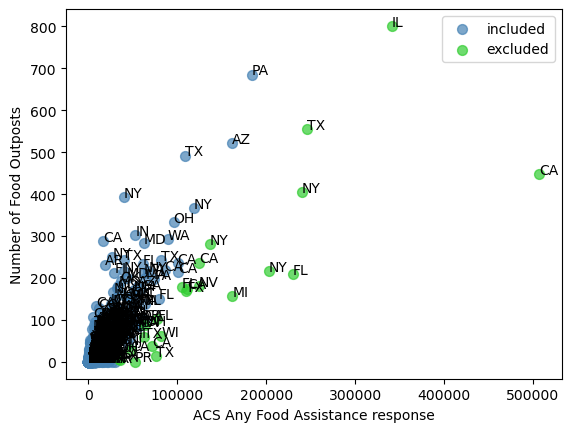

In [173]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

df['scoped'] = df['student_resid'] < 3
df_scoped = df[df['scoped']]
df_excluded = df[~df['scoped']]

# scatter points
ax.scatter(df_scoped['x'], df_scoped['y'], color='steelblue', label='included', s=50, alpha=0.7)
ax.scatter(df_excluded['x'], df_excluded['y'], color='limegreen', label='excluded', s=50, alpha=0.7)

# add a line (here: simple y = x trend)
# ax.plot(df['coverage_step_metric'], df['y_pred'], color="tomato", linewidth=1, label="fitted line")

# or a horizontal/vertical reference line:
# ax.axhline(3.5, color="gray", linestyle="--")
# ax.axvline(2.5, color="gray", linestyle="--")

ax.set_xlabel("ACS Any Food Assistance response")
ax.set_ylabel("Number of Food Outposts")
ax.legend()

for i, txt in enumerate(df['state_code']):
    ax.annotate(txt, (df.iloc[i]['x'], df.iloc[i]['y']))

plt.show()

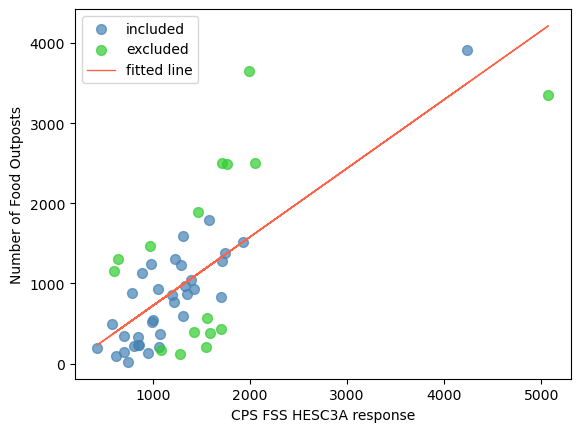

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

df['scoped'] = df['r2_drop_share'] < 0.009214722664545382
df_scoped = df[df['scoped']]
df_excluded = df[~df['scoped']]

# scatter points
ax.scatter(df_scoped['x'], df_scoped['y'], color='steelblue', label='included', s=50, alpha=0.7)
ax.scatter(df_excluded['x'], df_excluded['y'], color='limegreen', label='excluded', s=50, alpha=0.7)

# add a line (here: simple y = x trend)
ax.plot(df['x'], df['y_pred'], color="tomato", linewidth=1, label="fitted line")

# or a horizontal/vertical reference line:
# ax.axhline(3.5, color="gray", linestyle="--")
# ax.axvline(2.5, color="gray", linestyle="--")

ax.set_xlabel("CPS FSS HESC3A response")
ax.set_ylabel("Number of Food Outposts")
ax.legend()
plt.show()

In [43]:
df_scoped = df[df['scoped']]


In [45]:
df_excluded = df[~df['scoped']]

In [97]:
df = pandas.read_sql("select * from counties_metrics", con=engine)

In [100]:
df.columns

Index(['id', 'ct_population', 'ct_households',
       'ct_households_any_food_assistance',
       'ct_households_snap_food_assistance',
       'ct_households_snap_food_assistance_disability', 'ct_housingunits',
       'ct_housingunits_owner_occupied',
       'ct_housingunits_owner_occupied_no_vehicle',
       'ct_housingunits_renter_occupied',
       'ct_housingunits_renter_occupied_no_vehicle',
       'ct_poverty_determined_population', 'ct_poverty_income_ratio_lt_50pct',
       'ct_poverty_income_ratio_lte_99pct',
       'ct_poverty_income_ratio_lte_124pct',
       'ct_poverty_income_ratio_lte_149pct',
       'ct_poverty_income_ratio_lte_184pct',
       'ct_poverty_income_ratio_lte_199pct',
       'ct_poverty_income_ratio_gt_200pct', 'ct_income_below_poverty',
       'ct_income_below_poverty_lt_6yo', 'ct_income_below_poverty_lte_11yo',
       'ct_income_below_poverty_lte_17yo', 'ct_snap_retailers',
       'ct_food_outposts', 'fp', 'name', 'state_name', 'state_code',
       'state_id'

In [52]:
df['scoped'] = df['r2_drop_share'] < 0.009214722664545382

In [63]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = pandas.read_sql("select * from counties_metrics", con=engine)
model = ols('x ~ y', data=df).fit()
stud_res = model.outlier_test()
combined_df = df.join(stud_res)

In [102]:
df.groupby(['state_id']).sum(

In [104]:
df.columns

Index(['id', 'ct_population', 'ct_households',
       'ct_households_any_food_assistance',
       'ct_households_snap_food_assistance',
       'ct_households_snap_food_assistance_disability', 'ct_housingunits',
       'ct_housingunits_owner_occupied',
       'ct_housingunits_owner_occupied_no_vehicle',
       'ct_housingunits_renter_occupied',
       'ct_housingunits_renter_occupied_no_vehicle',
       'ct_poverty_determined_population', 'ct_poverty_income_ratio_lt_50pct',
       'ct_poverty_income_ratio_lte_99pct',
       'ct_poverty_income_ratio_lte_124pct',
       'ct_poverty_income_ratio_lte_149pct',
       'ct_poverty_income_ratio_lte_184pct',
       'ct_poverty_income_ratio_lte_199pct',
       'ct_poverty_income_ratio_gt_200pct', 'ct_income_below_poverty',
       'ct_income_below_poverty_lt_6yo', 'ct_income_below_poverty_lte_11yo',
       'ct_income_below_poverty_lte_17yo', 'ct_snap_retailers',
       'ct_food_outposts', 'fp', 'name', 'state_name', 'state_code',
       'state_id'

In [65]:
stud_res = model.outlier_test()

In [72]:
combined_df = df.join(stud_res)

Text(0, 0.5, 'Studentized Residuals')

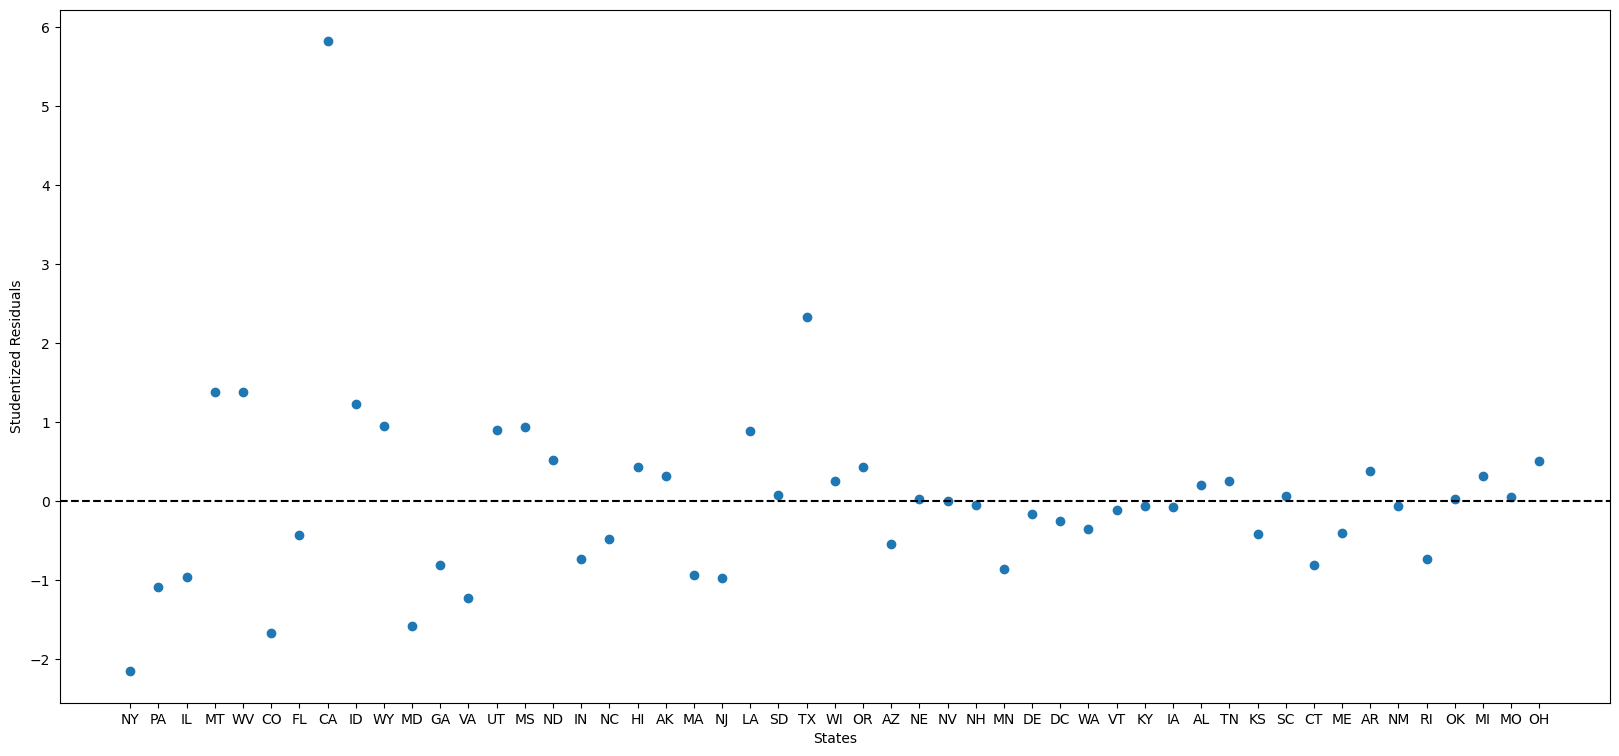

In [80]:
#define predictor variable values and studentized residuals
x = combined_df['state_code']
y = combined_df['student_resid']

plt.figure(figsize=(20, 9))

#create scatterplot of predictor variable vs. studentized residuals
plt.scatter(x, y)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('States')
plt.ylabel('Studentized Residuals') 

In [79]:
combined_df

,state_id,state_code,r2,x,y,y_pred,residual,sse_contrib,r2_drop_share,student_resid,unadj_p,bonf(p)
0,36,NY,0.541938,1989,3653,1570.894359,2082.105641,4.335164e+06,1.017967e-01,-2.156629,3.607317e-02,1.000000
1,42,PA,0.541938,1712,2502,1333.369810,1168.630190,1.365697e+06,3.206877e-02,-1.090650,2.808718e-01,1.000000
2,17,IL,0.541938,1768,2492,1381.389214,1110.610786,1.233456e+06,2.896356e-02,-0.968163,3.378163e-01,1.000000
3,30,MT,0.541938,1552,204,1196.171515,-992.171515,9.844043e+05,2.311541e-02,1.373223,1.760639e-01,1.000000
4,54,WV,0.541938,1703,434,1325.652406,-891.652406,7.950440e+05,1.866892e-02,1.378772,1.743568e-01,1.000000
5,08,CO,0.541938,644,1308,417.571189,890.428811,7.928635e+05,1.861772e-02,-1.675360,1.003672e-01,1.000000
6,12,FL,0.541938,2054,2501,1626.631167,874.368833,7.645209e+05,1.795219e-02,-0.428455,6.702363e-01,1.000000
7,06,CA,0.541938,5072,3358,4214.534011,-856.534011,7.336505e+05,1.722730e-02,5.821780,4.687218e-07,0.000024
8,16,ID,0.541938,1588,377,1227.041132,-850.041132,7.225699e+05,1.696711e-02,1.225680,2.262991e-01,1.000000
9,56,WY,0.541938,1284,125,966.364371,-841.364371,7.078940e+05,1.662250e-02,0.951798,3.459676e-01,1.000000


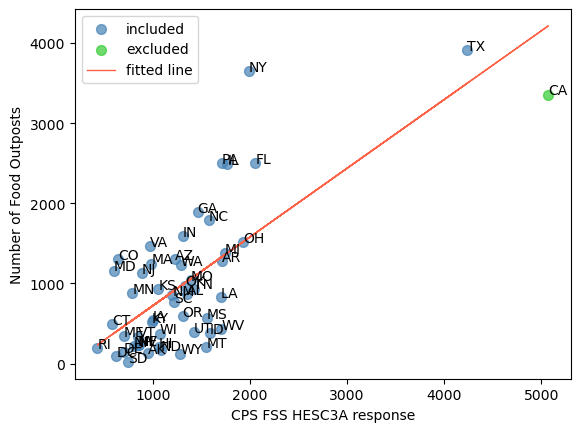

In [96]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

combined_df['scoped'] = abs(combined_df['student_resid']) < 3
df_scoped = combined_df[combined_df['scoped']]
df_excluded = combined_df[~combined_df['scoped']]

# scatter points
ax.scatter(df_scoped['x'], df_scoped['y'], color='steelblue', label='included', s=50, alpha=0.7)
ax.scatter(df_excluded['x'], df_excluded['y'], color='limegreen', label='excluded', s=50, alpha=0.7)

# add a line (here: simple y = x trend)
ax.plot(combined_df['x'], combined_df['y_pred'], color="tomato", linewidth=1, label="fitted line")

# or a horizontal/vertical reference line:
# ax.axhline(3.5, color="gray", linestyle="--")
# ax.axvline(2.5, color="gray", linestyle="--")

ax.set_xlabel("CPS FSS HESC3A response")
ax.set_ylabel("Number of Food Outposts")
ax.legend()
for i, txt in enumerate(combined_df['state_code']):
    ax.annotate(txt, (combined_df.iloc[i]['x'], combined_df.iloc[i]['y']))

plt.show()

In [95]:
combined_df.iloc[0]['x']

state_id                     36
state_code                   NY
r2                     0.541938
x                          1989
y                          3653
y_pred              1570.894359
residual            2082.105641
sse_contrib      4335163.900035
r2_drop_share          0.101797
student_resid         -2.156629
unadj_p                0.036073
bonf(p)                     1.0
scoped                     True
Name: 0, dtype: object

In [204]:
# Run studentized residuals for outlier detection

import pandas
import numpy as np
query = """
select
    id,
    name,
    state_id,
    state_name,
    ct_population,
    ct_snap_retailers,
    ct_income_below_poverty,
    ct_poverty_determined_population,
    1.0 * ct_income_below_poverty / ct_poverty_determined_population as pct_poverty,
    1.0 * ct_snap_retailers / ct_population as pct_snap_per_capita
from counties_metrics
where state_id <> '72'
"""
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = pandas.read_sql(query, con=engine)
model = ols('ct_income_below_poverty ~ ct_snap_retailers', data=df).fit()

In [328]:
# Run studentized residuals for outlier detection

import pandas
import numpy as np
query = """
select
   id,
   name,
   state_id,
   state_name,
   state_code,
   ct_population,
   ct_households,
   ct_income_below_poverty,
   ct_poverty_determined_population,
   ct_food_outposts,
   ct_snap_retailers,
   pct_metric,
   pct_snap_retailers,
   fa_pop,
   fa_fi_rate,
   fa_fi_pop,
   fa_child_fi_rate,
   fa_child_fi_pop,
   fa_child_fi_below_pct,
   fa_child_fi_above_pct,
   fa_cpm,
   fa_annual_gap_funding_needed,
   1.0 * fa_annual_gap_funding_needed / fa_cpm as fa_gap_meals_needed,
   1.0 - (1.0 * ct_snap_retailers / (ct_snap_retailers + ct_food_outposts)) as diff_snap_outposts,
   ct_snap_retailers - ct_food_outposts as ct_delta_snap_outposts
from counties_analytics_view
where state_code <> 'PR'
and ct_snap_retailers + ct_food_outposts > 0
"""
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = pandas.read_sql(query, con=engine)
model = ols('fa_gap_meals_needed ~ pct_metric', data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     fa_gap_meals_needed   R-squared:                       0.001
Model:                             OLS   Adj. R-squared:                  0.000
Method:                  Least Squares   F-statistic:                     1.869
Date:                 Wed, 17 Dec 2025   Prob (F-statistic):              0.172
Time:                         03:50:19   Log-Likelihood:                -54547.
No. Observations:                 3127   AIC:                         1.091e+05
Df Residuals:                     3125   BIC:                         1.091e+05
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.314e+06   3.87e+05      8.565      0.000    2.55e+06    4.07e+06
pct_metric -4.125e+06   3.02e+06     -1.367      0.172      -1e+07    1.79e+06
==============================================================================
Omnibus:                     5878.003   Durbin-Watson:                   1.698
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         12646215.099
Skew:                          13.952   Prob(JB):                         0.00
Kurtosis:                     313.294   Cond. No.                         18.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

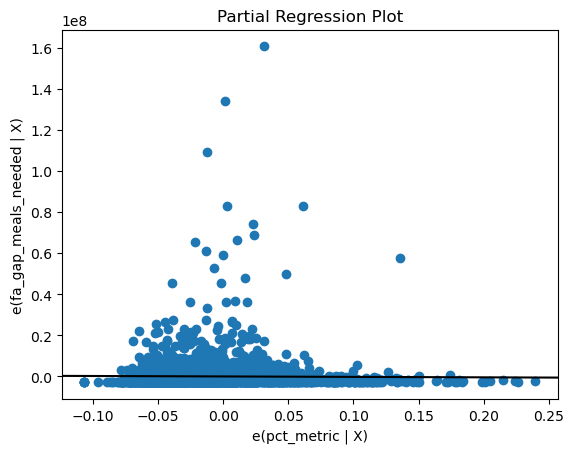

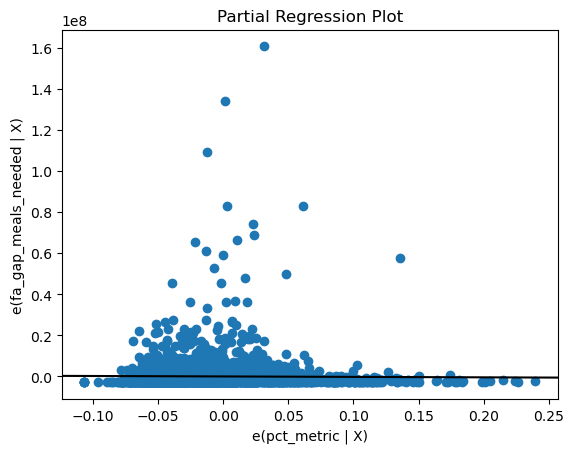

In [329]:
sm.graphics.plot_partregress('fa_gap_meals_needed', 'pct_metric', [], data=df[df['diff_snap_outposts']>0.1], obs_labels=False)

In [330]:
%%sql


WITH state_level_analytics AS (
  select
     state_code,
     COUNT(1) as ct_counties_evaluated,
     SUM(ct_snap_retailers) as total_snap_retailers,
     SUM(ct_food_outposts) as total_food_outposts,
     percentile_cont(0.5) within group (order by pct_metric) as median_risk_metric,
     1.0 * SUM(ct_snap_retailers) / NULLIF((SUM(ct_snap_retailers) + SUM(ct_food_outposts)),0)::float as proportion_snap_outposts,
     SUM(ct_population) as total_population,
     SUM(ct_income_below_poverty) / SUM(ct_poverty_determined_population)::float as overall_poverty_rate
  from counties_analytics_view
  where state_code <> 'PR'
  and filter_step_bucket >= 2
  and state_code <> 'CA'
  group by state_code
),
nation_analytics AS (
  select
     COUNT(1) as ct_counties_evaluated,
     SUM(ct_snap_retailers) as total_snap_retailers,
     SUM(ct_food_outposts) as total_food_outposts,
     percentile_cont(0.5) within group (order by pct_metric) as median_risk_metric,
     1.0 * SUM(ct_snap_retailers) / NULLIF((SUM(ct_snap_retailers) + SUM(ct_food_outposts)),0)::float as proportion_snap_outposts,
     SUM(ct_population) as total_population,
     SUM(ct_income_below_poverty) / SUM(ct_poverty_determined_population)::float as overall_poverty_rate
  from counties_analytics_view
  where state_code <> 'PR'
  and filter_step_bucket >= 2
  and state_code <> 'CA'
)
SELECT
    state_code as "State",
    ct_counties_evaluated as "At-risk Counties",
    total_snap_retailers as "Total SNAP Retailers",
    total_food_outposts as "Total Food Outposts",
    round(median_risk_metric::numeric,4) as "Median Risk Metric",
    round(proportion_snap_outposts::numeric,4) as "Proportion SNAP vs Outposts",
    total_population as "Population",
    round(overall_poverty_rate::numeric,2) as "Poverty Rate"
FROM state_level_analytics
ORDER BY median_risk_metric DESC;

Running query in 'postgresql://healthgps:***@db/healthgps'

37 rows affected.

State,At-risk Counties,Total SNAP Retailers,Total Food Outposts,Median Risk Metric,Proportion SNAP vs Outposts,Population,Poverty Rate
HI,1,0,0,None,None,43,0.32
SD,12,82,5,0.3249,0.9425,59494,0.39
NY,1,1943,216,0.2425,0.9000,1419250,0.27
AL,21,637,52,0.2220,0.9245,487419,0.23
NV,1,4,0,0.2207,1.0000,1660,0.22
KY,48,1348,153,0.2169,0.8981,929981,0.25
MS,47,1616,352,0.2124,0.8211,1309394,0.25
TX,42,2568,280,0.2120,0.9017,2519277,0.25
WI,1,7,0,0.2119,1.0000,4256,0.21
GA,58,2235,413,0.2116,0.8440,1614805,0.23
